# Breast Cancer Diagnosis Analysis

This notebook loads the WDBC dataset, trains a Random Forest classifier to predict diagnosis (Malignant vs Benign), and interprets the model using SHAP and LIME.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import shap
import lime
import lime.lime_tabular

# Set plot style
sns.set(style="whitegrid")

## 1. Load Data
Loading the dataset and assigning column names based on `wdbc.names`.

In [2]:
# Define column names
features_mean = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']
features_se = ['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se']
features_worst = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

columns = ['ID', 'Diagnosis'] + features_mean + features_se + features_worst

# Load data
df = pd.read_csv('wdbc.data', names=columns, header=None)

# Display first few rows
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Preprocessing
- Drop ID column
- Encode Diagnosis (M=1, B=0)
- Split into Train and Test sets

In [3]:
# Drop ID column as it's not useful for prediction
df = df.drop('ID', axis=1)

# Encode Diagnosis: Malignant (M) -> 1, Benign (B) -> 0
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

print("Class encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split features (X) and target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Class encoding: {'B': np.int64(0), 'M': np.int64(1)}
Training shape: (455, 30)
Testing shape: (114, 30)


## 3. Train Random Forest Model

In [4]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 4. Evaluate Model

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:


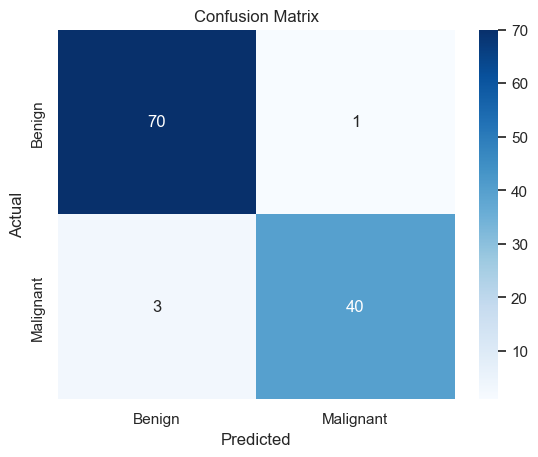

In [5]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## 5. SHAP Analysis
SHAP (SHapley Additive exPlanations) values explain the output of a machine learning model.

SHAP Summary Plot (Feature Importance):


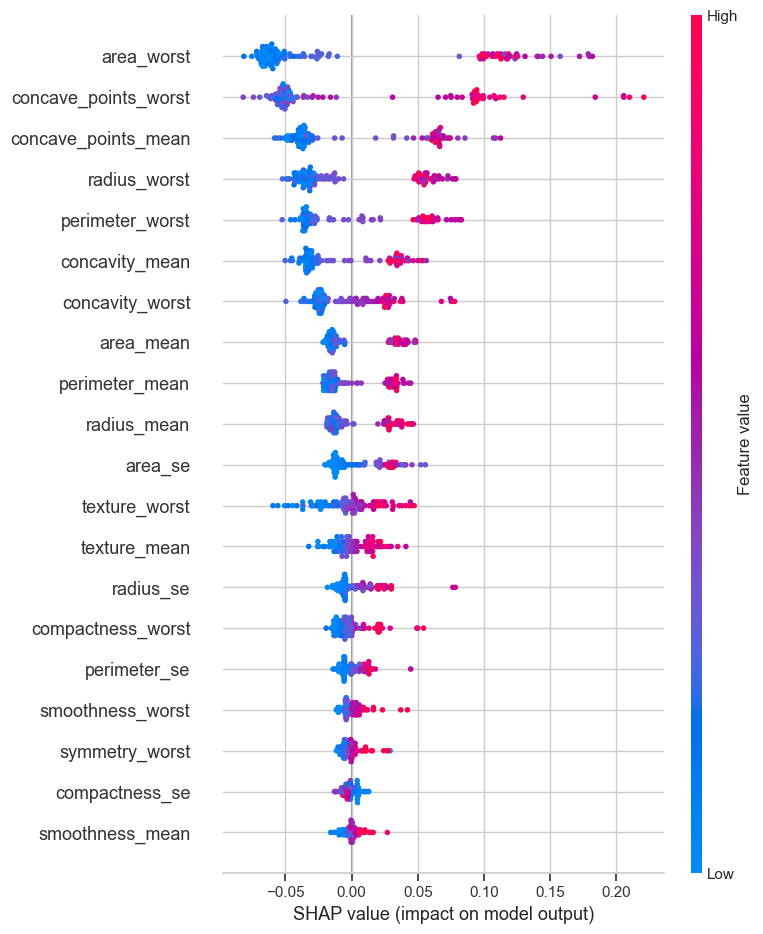

In [6]:
# Initialize JS visualization code for SHAP
shap.initjs()

# Create object that can calculate shap values
# Using TreeExplainer which is optimized for Random Forests
explainer = shap.TreeExplainer(rf_model)

# Calculate Shap values
shap_values = explainer.shap_values(X_test)

# Summary Plot
print("SHAP Summary Plot (Feature Importance):")
shap.summary_plot(shap_values[:,:,1], X_test) # index 1 for the positive class (Malignant)

## 6. LIME Analysis
LIME (Local Interpretable Model-agnostic Explanations) explains the predictions of any classifier.

Explaining instance 10
True Class: Benign


C:\Users\mina_\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\mina_\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\mina_\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always 

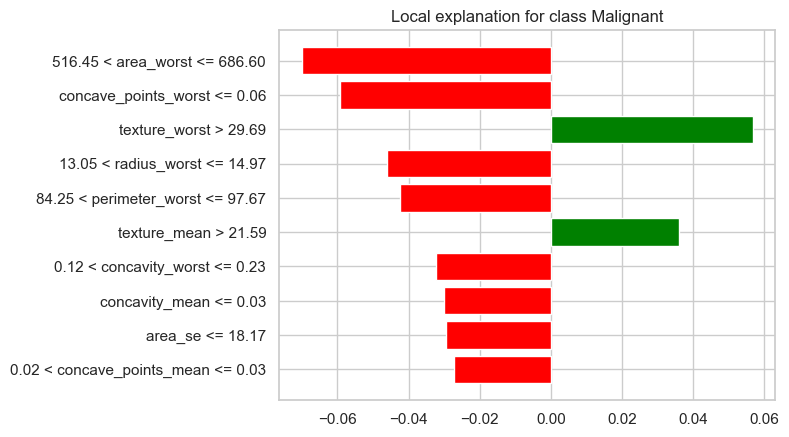

In [7]:
# Create a LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Benign', 'Malignant'],
    mode='classification'
)

# Pick a random instance from test set to explain
idx = 10 
instance = X_test.iloc[idx]
true_class = y_test.iloc[idx]

print(f"Explaining instance {idx}")
print(f"True Class: {'Malignant' if true_class == 1 else 'Benign'}")

# Generate explanation
exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=rf_model.predict_proba
)

# Show the explanation as a pyplot figure
fig = exp.as_pyplot_figure()
plt.show()